In [1]:
library(Seurat)
library(scattermore)
library(data.table)
library(patchwork)
library(arrow)
options(future.globals.maxSize = 1000 * 1024^2)
options(Seurat.object.assay.version = "v4")
library(tidyverse)
library(cowplot)
library(patchwork)
library(WGCNA)
library(hdWGCNA)
library(ggplot2)
library(dplyr)
library(ggnewscale)
# enable parallel processing for network analysis 
enableWGCNAThreads(nThreads = 12)

# using the cowplot theme for ggplot
theme_set(theme_cowplot())

# set random seed for reproducibility
set.seed(12345)

Attaching SeuratObject

‘SeuratObject’ was built under R 4.3.1 but the current version is
4.3.3; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed

‘SeuratObject’ was built with package ‘Matrix’ 1.6.1.1 but the current
version is 1.6.5; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode


Attaching package: ‘arrow’


The following object is masked from ‘package:utils’:

    timestamp


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()      masks data.t

Allowing parallel execution with up to 12 working processes.


In [2]:
combined_obj <- readRDS("../Data/GSE280318_hdWGCNA.rds")


In [3]:
niches <- readRDS('../DataGSE280318_sptail_regions.rds')
identical(rownames(niches),rownames(combined_obj[[]]))
combined_obj$niches2 <- niches$niches2
combined_obj$X <- niches$X
combined_obj$Y <- niches$Y
combined_obj$niches3 <- case_match(
  combined_obj$niches2,
  "CRC1_1"   ~ "Normal Epithelial cell-enriched",
  "CRC1_2"   ~ "CAF-enriched",
  "CRC1_3"   ~ "vSM-enriched",
  "CRC1_4"   ~ "tumor cell-enriched",
  "CRC1_5"   ~ "immune cell-enriched",
  "CRC1_6"   ~ "other",
  "CRC2_1"   ~ "Normal Epithelial cell-enriched",
  "CRC2_2"   ~ "tumor cell-enriched",
  "CRC2_3"   ~ "vSM-enriched",
  "CRC2_4"   ~ "other",
  "CRC2_5"   ~ "CAF-enriched",
  "CRC5_1"   ~ "CAF-enriched",
  "CRC5_2"   ~ "Normal Epithelial cell-enriched",
  "CRC5_3"   ~ "immune cell-enriched",
  "CRC5_4"   ~ "other",
  "CRC5_5"   ~ "tumor cell-enriched",
  "CRC5_6"   ~ "vSM-enriched",
)

[1] TRUE

  Power    SFT.R.sq      slope truncated.R.sq  mean.k. median.k.   max.k.
1     1 0.018810229  0.5687350      0.5468615 740.6956  764.0032 879.8977
2     2 0.003839152 -0.1270940      0.3075425 481.1535  502.3501 684.2517
3     3 0.121409994 -0.4589232      0.1301284 325.5505  336.8201 553.3282
4     4 0.285246701 -0.5914936      0.1559530 229.1993  229.5065 461.4634
5     5 0.419488267 -0.6847389      0.2598519 167.3911  158.3549 394.0035
6     6 0.577515778 -0.7498177      0.4601045 126.2565  110.8541 342.3998


Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the hdWGCNA package.
  Please report the issue to the authors.”


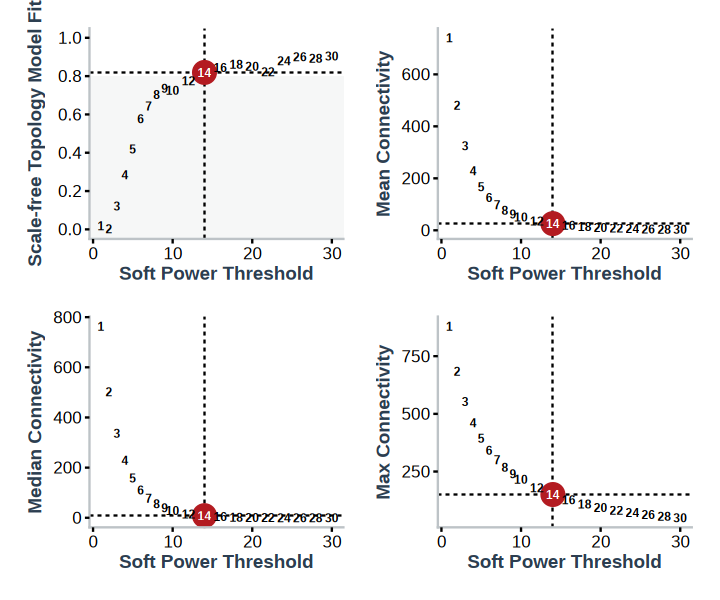

In [4]:
# Fig 3A
options(repr.plot.width = 6, repr.plot.height = 5) 

raw_plots <- PlotSoftPowers(combined_obj)
beautified_plots <- lapply(raw_plots, function(p) {

  if (is.null(p)) return(p)
  
  p <- p + 
    theme_classic(base_size = 11) +
    theme(
      plot.title = element_text(size = 11, face = "bold", color = "#2C3E50", hjust = 0.5, margin = margin(b = 10)),
      axis.title = element_text(size = 11, face = "bold", color = "#2C3E50"),
      axis.text = element_text(size = 10),
      axis.line = element_line(color = "#BDC3C7", linewidth = 0.5),
      plot.margin = margin(t = 10, r = 10, b = 10, l = 10, unit = "pt")
    )
  
  
  for (i in seq_along(p$layers)) {
    geom_type <- p$layers[[i]]$geom
    
    
    if (inherits(geom_type, "GeomHline") || inherits(geom_type, "GeomVline")) {
      p$layers[[i]]$geom_params$color <- "#95A5A6" 
      p$layers[[i]]$geom_params$linewidth <- 0.45  
      p$layers[[i]]$geom_params$size <- 0.45       
    }
    
    if (inherits(geom_type, "GeomRect")) {
      p$layers[[i]]$aes_params$fill <- "#F2F4F4"   
      p$layers[[i]]$aes_params$alpha <- 0.7
    }
    
    if (inherits(geom_type, "GeomText")) {
      
      col_param <- p$layers[[i]]$aes_params$colour
      is_white_label <- FALSE
      if (!is.null(col_param)) {
        if (any(col_param %in% c("white", "#FFFFFF"))) {
          is_white_label <- TRUE
        }
      }
      
      if (is_white_label) {
        p$layers[[i]]$aes_params$size <- 2.5      
        p$layers[[i]]$aes_params$fontface <- "bold"
      } else {
        p$layers[[i]]$aes_params$size <- 4       
        p$layers[[i]]$aes_params$colour <- "#7F8C8D"
      }
    }
    
    
    if (inherits(geom_type, "GeomPoint")) {
      p$layers[[i]]$aes_params$colour <- "#B31B21" 
      p$layers[[i]]$aes_params$size <- 6.0         
    }
  }
  
  return(p)
})

wrap_plots(beautified_plots, ncol = 2)

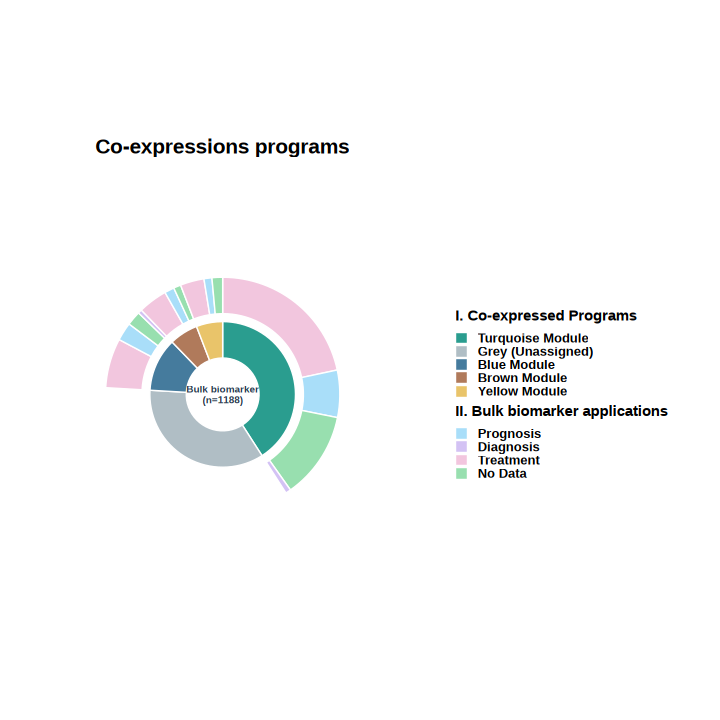

In [5]:
# Fig 3B
options(repr.plot.width = 6, repr.plot.height = 6) 

# ==============
# 1. set up data
# ==============
raw_data <- list(
  turquoise = c(415, 125, 230, 14),
  grey      = c(356, 103, 106, 9),  
  blue      = c(38, 14, 11, 3),
  brown     = c(12, 4, 3, 0),
  yellow    = c(9, 3, 4, 0)
)

element_names <- c("Prognosis", "Diagnosis", "Treatment", "No Data")
module_order  <- c("turquoise", "grey", "blue", "brown", "yellow")


# ------------------------------
#  A. first level data (Modules)
# ------------------------------
df_level1 <- data.frame(
  level1 = names(raw_data),
  value_raw = sapply(raw_data, sum),
  stringsAsFactors = FALSE
) %>%
  mutate(value_scaled = sqrt(value_raw)) %>% 
  mutate(level1 = factor(level1, levels = module_order)) %>%
  arrange(level1) %>%
  mutate(
    ymax = cumsum(value_scaled),
    ymin = ymax - value_scaled,
    xmin = 1.0,  
    xmax = 1.55,  
    label = paste0(toupper(substring(level1, 1, 1)), substring(level1, 2), "\n(n=", value_raw, ")"),
    x_center = (xmin + xmax) / 2,
    y_center = (ymin + ymax) / 2
  )

# ------------------------------
#  B. second level data (Elements)
# ------------------------------
l2_list <- list()
for(m in module_order) {
  if(m == "grey") next 
  
  m_row <- df_level1[df_level1$level1 == m, ]
  m_ymin <- m_row$ymin
  m_scaled_total <- m_row$value_scaled
  m_raw_total <- m_row$value_raw
  
  sub_df <- data.frame(
    level1 = m,
    level2 = element_names,
    sub_idx = 1:4,
    value_raw = raw_data[[m]],
    stringsAsFactors = FALSE
  ) %>%
    filter(value_raw > 0)
  
  sub_df <- sub_df %>%
    mutate(
      value_scaled = m_scaled_total * (value_raw / m_raw_total),
      ymax = m_ymin + cumsum(value_scaled),
      ymin = ymax - value_scaled,
      xmin = 1.67,  
      xmax = 2.22,  
      label = paste0(level2, "\n", value_raw),
      x_center = (xmin + xmax) / 2,
      y_center = (ymin + ymax) / 2
    )
  
  l2_list[[m]] <- sub_df
}
df_level2 <- do.call(rbind, l2_list)


# =======================
# 3.  Editorial Colorways
# =======================

palette_l1 <- c(
  "turquoise" = "#2A9D8F",  
  "grey"      = "#B0BEC5",  
  "blue"      = "#457B9D",  
  "brown"     = "#B07A5B",  
  "yellow"    = "#E9C46A"   
)

palette_l2 <- c(
  "Prognosis" = "#F2C6DE",  
  "Diagnosis" = "#A9DEF9",  
  "Treatment" = "#98DFAF",  
  "No Data" = "#D3C2F4"   
)


ggplot() +
  geom_rect(
    data = df_level1,
    aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, fill = level1),
    color = "white", linewidth = 0.3
  ) +
  scale_fill_manual(
    name = "I. Co-expressed Programs", 
    values = palette_l1,
    labels = c("Turquoise Module", "Grey (Unassigned)", "Blue Module", "Brown Module", "Yellow Module")
  ) +
  
  new_scale_fill() + 
  geom_rect(
    data = df_level2,
    aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, fill = level2),
    color = "white", linewidth = 0.3
  ) +
  scale_fill_manual(
    name = "II. Bulk biomarker applications", 
    values = palette_l2,
    labels = c("Prognosis", "Diagnosis", "Treatment", "No Data")
  ) +
  new_scale_fill() + 
  coord_polar(theta = "y") +
  xlim(0.45, 2.9) + 
  annotate(
    "text",
    x = 0.45, 
    y = 0, 
    label = "Bulk biomarker\n(n=1188)",
    size = 2,                 
    fontface = "bold",   
    color = "#2C3E50",          
    lineheight = 0.95           
  ) +
  theme_void() +
  theme(
    legend.position = "right",
    legend.box = "vertical",
    legend.box.spacing = unit(18, "pt"), 
    legend.spacing.y = unit(4, "pt"),    
    legend.key.size = unit(8, "pt"),    
    legend.title = element_text(size = 8.5, face = "bold"),
    legend.text = element_text(size = 7.5,face = "bold"),
    plot.title = element_text(
      hjust = 0.5, 
      face = "bold", 
      size = 12, 
      margin = margin(b=20, t=10)
    ),
    plot.margin = margin(12, 12, 12, 12, unit = "pt")
  ) +
  labs(
    title = "Co-expressions programs"
  )


Warning message in plot_theme(plot):
“The `legend.box.justify` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.box.justify` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.box.justify` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.box.justify` theme element is not defined in the element hierarchy.”


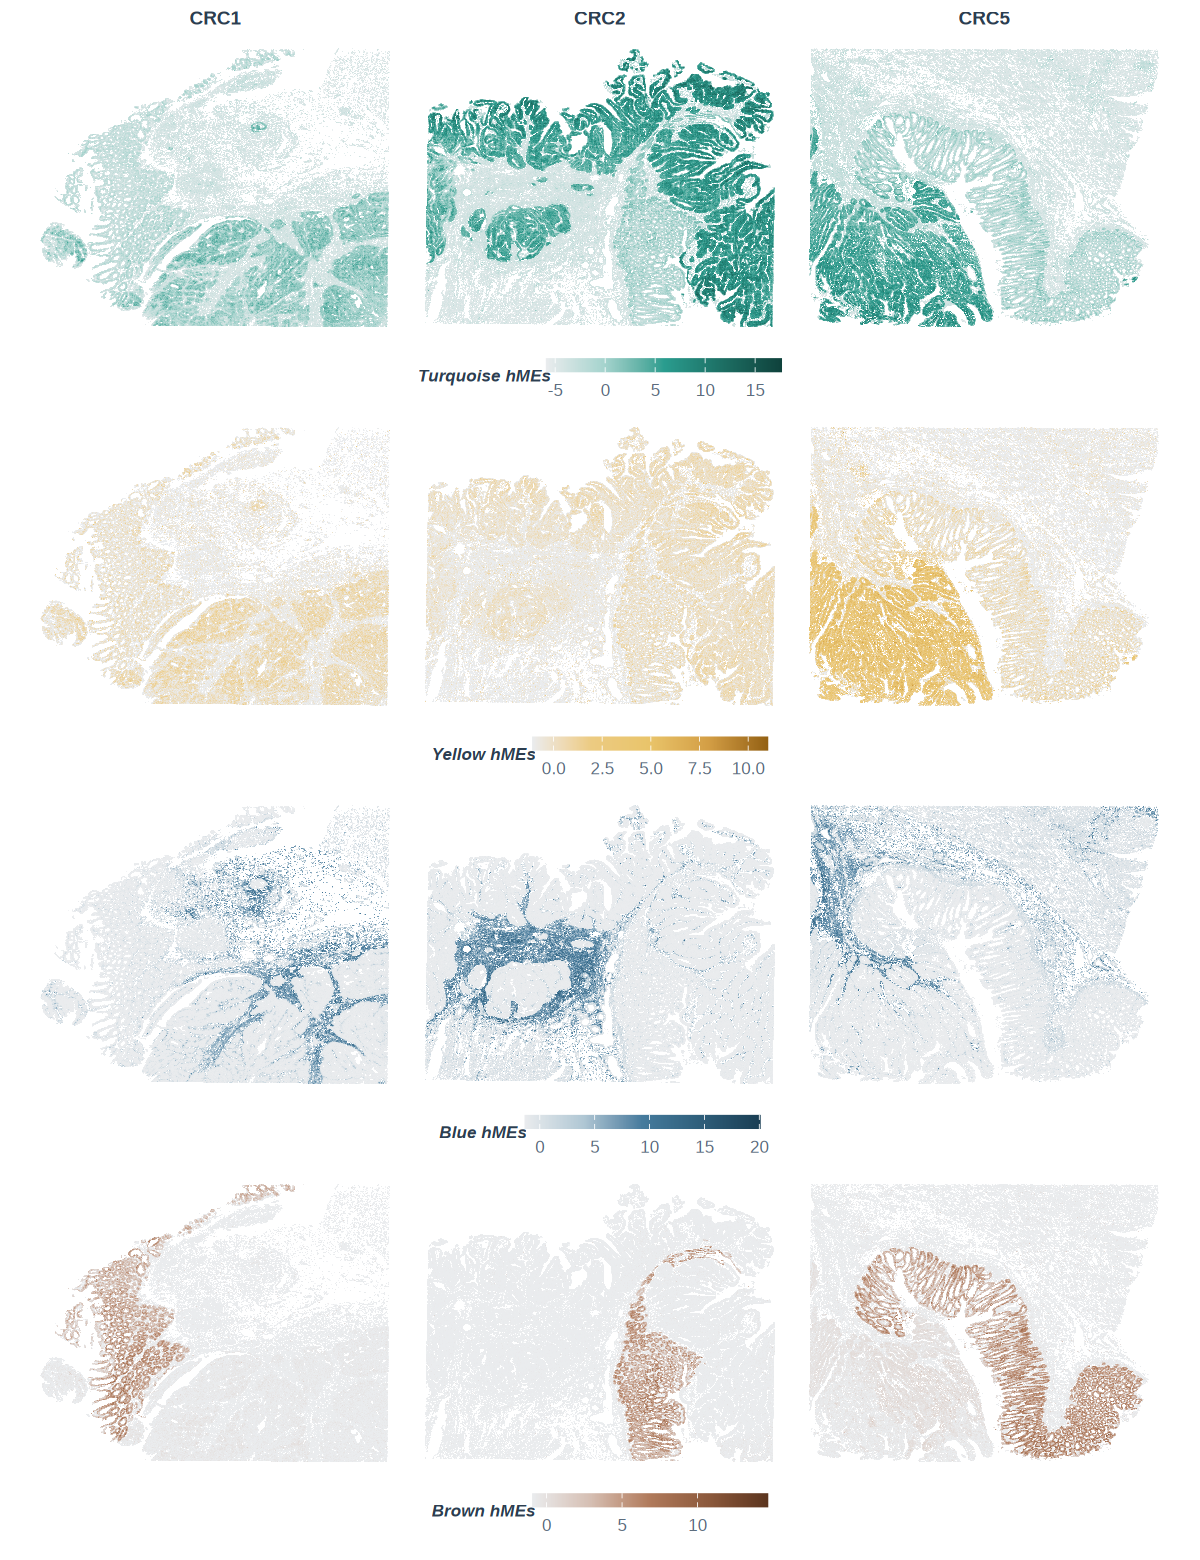

In [6]:
# Fig 3C
options(repr.plot.width = 10, repr.plot.height = 13) 

mods <- c('turquoise','yellow','blue','brown')
slices <- c('CRC1','CRC2','CRC5')

plot_data_list <- list()
for (sl in slices) {
  # spatial coords
  coords <- combined_obj[[]] %>% filter(slice == sl  & DeconvolutionClass == "singlet")
  x_col <- coords[,'X']
  y_col <- coords[,'Y']
  
  coords_clean <- data.frame(
    X = x_col,
    Y = y_col,
    row.names = rownames(coords)
  )
  
  # MEs
  slice_cells <- intersect(rownames(coords_clean), colnames(combined_obj))
  meta_sub <- combined_obj@meta.data[slice_cells, mods, drop = FALSE]
  
  combined_sub <- cbind(coords_clean[slice_cells, ], meta_sub)
  combined_sub$slice <- sl
  plot_data_list[[sl]] <- combined_sub
}
all_points_df <- do.call(rbind, plot_data_list)


module_palettes <- list(
  turquoise = c("#EAECEE","#A4D3CD", "#2A9D8F", "#1D6F64", "#0F423C"), 
  blue      = c("#EAECEE","#B0C7D4", "#457B9D", "#2E5E7A", "#1A3E54"), 
  brown     = c( "#EAECEE","#D5BEB2", "#B07A5B", "#8C593C", "#5C351F"),   
  yellow    = c("#EAECEE","#ECCB82", "#E9C46A", "#D39E45", "#946113")  
)


theme_spatial_publication <- function(is_top_row = FALSE) {
  theme_minimal(base_size = 10) +
  theme(
    axis.text = element_blank(),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none", 
    
    plot.title = if (is_top_row) {
      element_text(hjust = 0.5, face = "bold", size = 11, color = "#2C3E50", margin = margin(b = 4))
    } else {
      element_blank()
    },
  
    plot.margin = margin(t = 0, r = 0, b = 0, l = 0, unit = "pt")
  )
}


row_plots_list <- list()

for (i in seq_along(mods)) {
  mod <- mods[i]
  is_top <- (i == 1) 
  
  current_palette <- module_palettes[[tolower(mod)]]
  if (is.null(current_palette)) {
    current_palette <- default_palette
  }
  
  global_range <- range(all_points_df[[mod]], na.rm = TRUE)
  mod_title <- paste0(toupper(substring(mod, 1, 1)), substring(mod, 2)) 
  
  
  slice_plots <- list()
  for (j in seq_along(slices)) {
    sl <- slices[j]
    sub_df <- all_points_df %>% filter(slice == sl)
    
    
    display_title <- sl
    
    p_sub <- ggplot(sub_df, aes(x = X, y = Y, color = .data[[mod]])) +
      
      geom_scattermore(pointsize = 2, pixels = c(1200, 1200)) + 
      scale_color_gradientn(colors = current_palette, limits = global_range) +
      #coord_fixed(ratio = 1) + 
      ggtitle(display_title) +
      theme_spatial_publication(is_top_row = is_top)
    
    slice_plots[[sl]] <- p_sub
  }
  
  
  p_legend_helper <- ggplot(all_points_df, aes(x = X, y = Y, color = .data[[mod]])) +
    geom_scattermore(pointsize = 1) +
    scale_color_gradientn(colors = current_palette, limits = global_range) +
    guides(
      color = guide_colorbar(
        direction = "horizontal",
        ticks = FALSE,
        title = paste(mod_title, "hMEs") 
      )
    ) +  
    theme(
      legend.position = "top",
      legend.key.spacing.y = unit(-2, "pt"),
      plot.margin = margin(0, 0, 0, 0),
      legend.justification = "center",legend.box.justify = "center",
      legend.margin = margin(t = 4, b = 2, l = 0, r = 0, unit = "pt"), 
      legend.key.width = unit(1, "cm"),  
      legend.key.height = unit(0.30, "cm"),  
      legend.title = element_text(size = 10, face = "bold.italic", color = "#2C3E50", margin = margin(b = 4)), 
      legend.text = element_text(size = 10, color = "#5D6D7E")
    )
  
  row_legend <- cowplot::get_legend(p_legend_helper)
  
  
  row_assembled <- ((slice_plots[[1]] | slice_plots[[2]] | slice_plots[[3]]) / row_legend) + 
    plot_layout(heights = c(1, 0.16))
  
  row_plots_list[[mod]] <- row_assembled
}


wrap_plots(row_plots_list, ncol = 1) +
  plot_layout(heights = rep(1, length(mods))) &
  theme(
    plot.background = element_rect(fill = "white", color = NA)
  )



Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_point()`).”


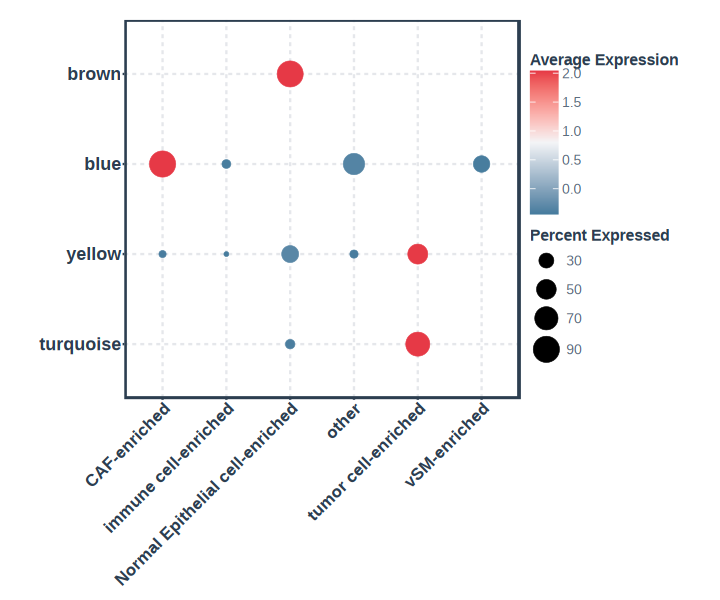

In [7]:
# Fig 3D
options(repr.plot.width = 6, repr.plot.height = 5) 


p <- DotPlot(
  combined_obj, 
  features = mods, 
  group.by = 'niches3', 
  dot.min = 0.1,
  dot.scale = 7.5 
)


p +
  coord_flip() + 
  scale_color_gradientn(
    colors = c("#457B9D", "#F4F5F7", "#E63946"), 
    name = "Relative\nExpression"
  ) +
  
  scale_size_continuous(
    range = c(1.0, 7), 
    name = "Percent\nExpressed (%)"
  ) +
  
  labs(x = NULL, y = NULL) +
  theme_bw(base_size = 4) +
  theme(
    
    panel.border = element_rect(color = "#2C3E50", fill = NA, size = 1.0),
    panel.grid.major = element_line(color = "#E5E7EB", size = 0.5, linetype = "dashed"),
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, face = "bold", color = "#2C3E50", size = 10),
    axis.text.y = element_text(face = "bold", color = "#2C3E50", size = 10.5),
    axis.ticks = element_line(color = "#2C3E50", size = 0.5),
    legend.title = element_text(size = 9, face = "bold", color = "#2C3E50"),
    legend.text = element_text(size = 8, color = "#5D6D7E"),
    legend.background = element_blank(),
    legend.box.background = element_blank(),
    plot.margin = margin(t = 12, r = 12, b = -10, l = 16, unit = "pt")
  )

In [8]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 16.04.6 LTS

Matrix products: default
BLAS/LAPACK: /home/amax/.local/share/mamba/envs/hdWGCNA2/lib/libopenblasp-r0.3.32.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=zh_CN.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=zh_CN.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=zh_CN.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=zh_CN.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ggnewscale_0.5.2            hdWGCNA_0.4.11             
 [3] enrichR_3.4                 SummarizedExperiment_1.32.0
 [5] Biobase_2.62.0              MatrixGenerics_1.14.0      
 [7] matrixStats_1.